In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

print("Корень проекта:", project_root)

Корень проекта: C:\Users\Анастасия\Documents\Projects\coperto-forecast


In [2]:
from src.features import make_features
print("make_features импортирована успешно")

make_features импортирована успешно


In [3]:
import pandas as pd
df = pd.read_csv(
    "../data/processed/restaurant_cleaned.csv",
    parse_dates=["date"]
)
print("Размер данных:", df.shape)
print(df["date"].min(), "—", df["date"].max())

Размер данных: (910, 17)
2017-01-02 00:00:00 — 2019-06-30 00:00:00


In [4]:
features_df = make_features(df)

print("Размер таблицы с признаками:", features_df.shape)
print("\nПризнаки:")
print(features_df.columns.tolist())

Размер таблицы с признаками: (910, 23)

Признаки:
['date', 'inside_sales', 'outside_sales', 'inside_covers', 'outside_covers', 'reserved_covers', 'walkin_covers', 'waitlist_covers', 'no_show_covers', 'no_show_parties', 'is_closed', 'restaurant_id', 'day_of_week', 'day_name', 'month', 'is_holiday', 'is_weekend', 'week_of_year', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_28']


In [5]:
missing = features_df.isna().sum()
print("Пропуски в признаках:")
print(missing[missing > 0])

Пропуски в признаках:
inside_covers       2
reserved_covers     2
walkin_covers       2
waitlist_covers     2
no_show_covers      2
no_show_parties     2
lag_1               3
lag_7               9
lag_14             16
rolling_mean_7     21
rolling_mean_28    84
dtype: int64


In [6]:
feature_columns = [
    "day_of_week",
    "is_weekend",
    "month",
    "week_of_year",
    "is_holiday",
    "lag_1",
    "lag_7",
    "lag_14",
    "rolling_mean_7",
    "rolling_mean_28"
]

print("Количество признаков:", len(feature_columns))
print(feature_columns)

Количество признаков: 10
['day_of_week', 'is_weekend', 'month', 'week_of_year', 'is_holiday', 'lag_1', 'lag_7', 'lag_14', 'rolling_mean_7', 'rolling_mean_28']


In [7]:
model_data = features_df[
    features_df["inside_covers"].notna()
    & features_df[feature_columns].notna().all(axis=1)
].copy()

print("Размер model_data:", model_data.shape)
print("Период:", model_data["date"].min(), "—", model_data["date"].max())
print("\nПропуски:")
print(model_data[feature_columns + ["inside_covers"]].isna().sum().sum())

Размер model_data: (824, 23)
Период: 2017-01-30 00:00:00 — 2019-06-30 00:00:00

Пропуски:
0


## Разделение данных

Не используем train_test_split, потому что тогда будущие наблюдения могут попасть в обучение.

In [8]:
# Пусть validation = 6 недель = 42 дня
valid_days = 42
validation_start = model_data["date"].max() - pd.Timedelta(days=valid_days - 1)
print("Последняя дата:", model_data["date"].max())
print("Начало validation:", validation_start)

Последняя дата: 2019-06-30 00:00:00
Начало validation: 2019-05-20 00:00:00


In [9]:
train_data = model_data[
    model_data["date"] < validation_start # идёт в обучение
].copy()

valid_data = model_data[
    model_data["date"] >= validation_start # в проверку
].copy()

print("Train:", train_data.shape)
print("Validation:", valid_data.shape)

print("\nTrain:")
print(train_data["date"].min(), "—", train_data["date"].max())

print("\nValidation:")
print(valid_data["date"].min(), "—", valid_data["date"].max())

Train: (782, 23)
Validation: (42, 23)

Train:
2017-01-30 00:00:00 — 2019-05-19 00:00:00

Validation:
2019-05-20 00:00:00 — 2019-06-30 00:00:00


In [10]:
print(
    "Последняя дата train:",
    train_data["date"].max()
)

print(
    "Первая дата validation:",
    valid_data["date"].min()
)

print(
    "\nЕсть пересечение:",
    train_data["date"].max() >= valid_data["date"].min()
)

Последняя дата train: 2019-05-19 00:00:00
Первая дата validation: 2019-05-20 00:00:00

Есть пересечение: False


## Seasonal Naive Baseline

Выбор сделан такой так как присутсвует выраженная недельная сезонность: суббота имеет высокий поток гостей, вторник — более низкий. Поэтому для прогноза сегодняшнего дня будем брать количество гостей ровно 7 дней назад:y^t=yt−7.

In [11]:
X_train = train_data[feature_columns]
y_train = train_data["inside_covers"]

X_valid = valid_data[feature_columns]
y_valid = valid_data["inside_covers"]

print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_valid:", X_valid.shape)
print("y_valid:", y_valid.shape)

X_train: (782, 10)
y_train: (782,)
X_valid: (42, 10)
y_valid: (42,)


In [12]:
print("\nПропуски в X_train:")
print(X_train.isna().sum().sum())

print("Пропуски в X_valid:")
print(X_valid.isna().sum().sum())

print("Пропуски в y_train:")
print(y_train.isna().sum())

print("Пропуски в y_valid:")
print(y_valid.isna().sum())


Пропуски в X_train:
0
Пропуски в X_valid:
0
Пропуски в y_train:
0
Пропуски в y_valid:
0


In [13]:
y_pred_baseline = valid_data["lag_7"].values

baseline_results = valid_data[
    ["date", "inside_covers", "lag_7"]
].copy()

baseline_results["prediction"] = y_pred_baseline

baseline_results = baseline_results.rename(
    columns={
        "inside_covers": "actual"
    }
)

print(baseline_results.head(10))

          date  actual  lag_7  prediction
868 2019-05-20   182.0  180.0       180.0
869 2019-05-21   186.0  162.0       162.0
870 2019-05-22   172.0  173.0       173.0
871 2019-05-23   168.0  170.0       170.0
872 2019-05-24   190.0  184.0       184.0
873 2019-05-25    22.0  209.0       209.0
874 2019-05-26   211.0  189.0       189.0
875 2019-05-27   179.0  182.0       182.0
876 2019-05-28   152.0  186.0       186.0
877 2019-05-29   176.0  172.0       172.0


### Посчитаем MAE, MAPE

In [14]:
from sklearn.metrics import mean_absolute_error

baseline_mae = mean_absolute_error(
    y_valid,
    y_pred_baseline
)

non_zero_mask = y_valid != 0

baseline_mape = (
    abs(
        (
            y_valid[non_zero_mask]
            - y_pred_baseline[non_zero_mask]
        )
        / y_valid[non_zero_mask]
    ).mean()
    * 100
)

print(f"Baseline MAE: {baseline_mae:.2f}")
print(f"Baseline MAPE: {baseline_mape:.2f}%")

Baseline MAE: 17.10
Baseline MAPE: 27.23%


In [15]:
baseline_results["absolute_error"] = (
    abs(
        baseline_results["actual"]
        - baseline_results["prediction"]
    )
)

print(
    baseline_results
    .sort_values("absolute_error", ascending=False)
    .head(10)
)

          date  actual  lag_7  prediction  absolute_error
873 2019-05-25    22.0  209.0       209.0           187.0
880 2019-06-01   184.0   22.0        22.0           162.0
876 2019-05-28   152.0  186.0       186.0            34.0
904 2019-06-25   144.0  175.0       175.0            31.0
909 2019-06-30   221.0  191.0       191.0            30.0
869 2019-05-21   186.0  162.0       162.0            24.0
874 2019-05-26   211.0  189.0       189.0            22.0
887 2019-06-08   205.0  184.0       184.0            21.0
883 2019-06-04   170.0  152.0       152.0            18.0
895 2019-06-16   179.0  195.0       195.0            16.0


## RandomForestRegressor

In [16]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

model = Pipeline([
    (
        "regressor",
        RandomForestRegressor(
            n_estimators=300,
            max_depth=10,
            min_samples_leaf=3,
            random_state=42,
            n_jobs=-1
        )
    )
])

print(model)

Pipeline(steps=[('regressor',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=3,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])


In [17]:
model.fit(X_train, y_train)
print("Модель обучена.")

Модель обучена.


In [18]:
y_pred_model = model.predict(X_valid)

print("Количество прогнозов:", len(y_pred_model))
print("Первые 10 прогнозов:")

for actual, prediction in zip(
    y_valid.head(10),
    y_pred_model[:10]
):
    print(
        f"Факт: {actual:.0f} | "
        f"Прогноз: {prediction:.2f}"
    )

Количество прогнозов: 42
Первые 10 прогнозов:
Факт: 182 | Прогноз: 173.89
Факт: 186 | Прогноз: 174.74
Факт: 172 | Прогноз: 175.10
Факт: 168 | Прогноз: 176.58
Факт: 190 | Прогноз: 189.67
Факт: 22 | Прогноз: 204.39
Факт: 211 | Прогноз: 180.32
Факт: 179 | Прогноз: 157.05
Факт: 152 | Прогноз: 170.73
Факт: 176 | Прогноз: 166.89


In [19]:
model_mae = mean_absolute_error(
    y_valid,
    y_pred_model
)

model_mape = (
    abs(
        (
            y_valid[non_zero_mask]
            - y_pred_model[non_zero_mask]
        )
        / y_valid[non_zero_mask]
    ).mean()
    * 100
)

print(f"Random Forest MAE: {model_mae:.2f}")
print(f"Random Forest MAPE: {model_mape:.2f}%")

Random Forest MAE: 12.74
Random Forest MAPE: 24.34%


In [20]:
comparison = pd.DataFrame({
    "model": [
        "Seasonal Naive",
        "Random Forest"
    ],
    "MAE": [
        baseline_mae,
        model_mae
    ],
    "MAPE (%)": [
        baseline_mape,
        model_mape
    ]
})

comparison

,model,MAE,MAPE (%)
0,Seasonal Naive,17.095238,27.231115
1,Random Forest,12.737521,24.337147


In [21]:
mae_improvement = ((baseline_mae - model_mae) / baseline_mae * 100)
mape_improvement = ((baseline_mape - model_mape) / baseline_mape * 100)
print(f"Улучшение MAE: {mae_improvement:.2f}%")
print(f"Улучшение MAPE: {mape_improvement:.2f}%")

Улучшение MAE: 25.49%
Улучшение MAPE: 10.63%


Очевидно лучше baseline

In [22]:
results = valid_data[
    ["date", "inside_covers"]
].copy()

results["baseline_prediction"] = y_pred_baseline
results["model_prediction"] = y_pred_model

results["baseline_error"] = abs(
    results["inside_covers"]
    - results["baseline_prediction"]
)

results["model_error"] = abs(
    results["inside_covers"]
    - results["model_prediction"]
)

results.head(10)

,date,inside_covers,baseline_prediction,model_prediction,baseline_error,model_error
868,2019-05-20,182.0,180.0,173.888294,2.0,8.111706
869,2019-05-21,186.0,162.0,174.744327,24.0,11.255673
870,2019-05-22,172.0,173.0,175.101450,1.0,3.101450
871,2019-05-23,168.0,170.0,176.575829,2.0,8.575829
872,2019-05-24,190.0,184.0,189.673316,6.0,0.326684
873,2019-05-25,22.0,209.0,204.393141,187.0,182.393141
874,2019-05-26,211.0,189.0,180.318995,22.0,30.681005
875,2019-05-27,179.0,182.0,157.052295,3.0,21.947705
876,2019-05-28,152.0,186.0,170.733134,34.0,18.733134
877,2019-05-29,176.0,172.0,166.894437,4.0,9.105563


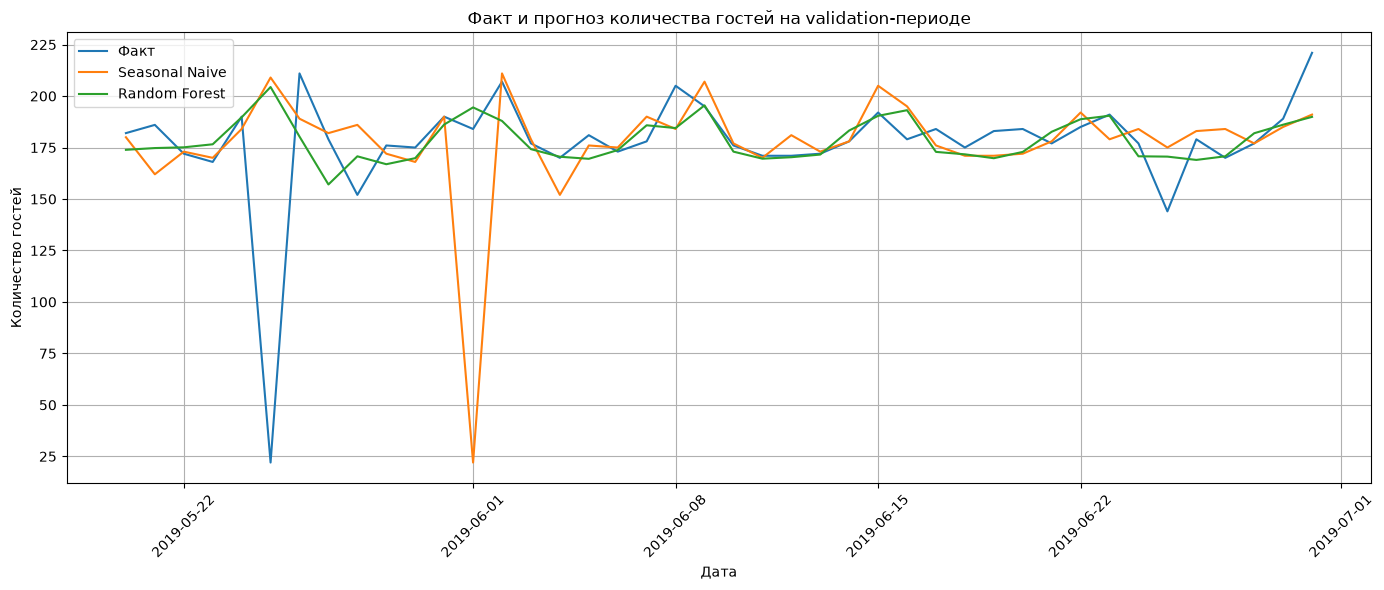

In [23]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(results["date"],results["inside_covers"],label="Факт")

plt.plot(results["date"],results["baseline_prediction"],label="Seasonal Naive")

plt.plot(results["date"],results["model_prediction"],label="Random Forest")

plt.xlabel("Дата")
plt.ylabel("Количество гостей")
plt.title("Факт и прогноз количества гостей на validation-периоде")
plt.legend()
plt.grid(True)
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [24]:
# Важность признаков
rf = model.named_steps["regressor"]

feature_importance = pd.DataFrame({
    "feature": feature_columns,
    "importance": rf.feature_importances_
})

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
)

feature_importance

,feature,importance
0,day_of_week,0.246572
3,week_of_year,0.187179
5,lag_1,0.132079
4,is_holiday,0.089467
7,lag_14,0.085843
9,rolling_mean_28,0.081802
6,lag_7,0.076738
8,rolling_mean_7,0.070424
2,month,0.024649
1,is_weekend,0.005246


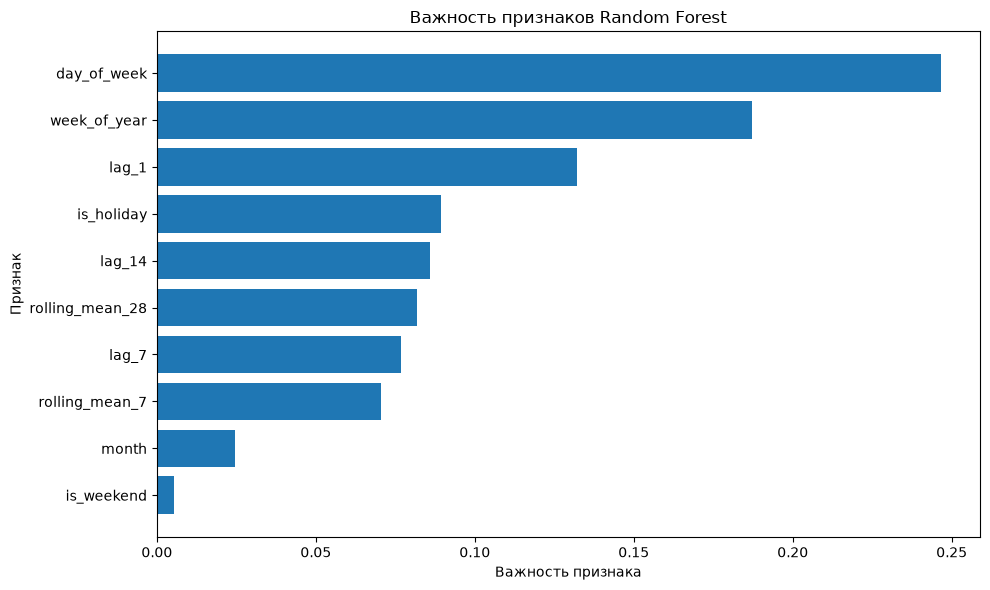

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.xlabel("Важность признака")
plt.ylabel("Признак")
plt.title("Важность признаков Random Forest")
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [26]:
import joblib
from pathlib import Path

model_path = project_root / "data" / "processed" / "restaurant_model.joblib"

joblib.dump(model, model_path)

print("Модель сохранена:")
print(model_path)

Модель сохранена:
C:\Users\Анастасия\Documents\Projects\coperto-forecast\data\processed\restaurant_model.joblib


In [27]:
print("Файл существует:", model_path.exists())

Файл существует: True


day_of_week оказался самым важным признаком, как и предполагалось. week_of_year также получил большую важность. Это говорит о том, что модель использует не только различия между днями недели, но и положение наблюдения внутри года.

### Проверки

In [28]:
from src.model import train_model
model = train_model(X_train,y_train)
print("Модель обучена")

Модель обучена


In [29]:
valid_predictions = model.predict(X_valid)

from src.validation import calculate_metrics

metrics = calculate_metrics(
    y_valid,
    valid_predictions
)

print(metrics)

{'MAE': 12.737521105545072, 'MAPE': np.float64(24.337146719433495)}


In [30]:
import joblib
from pathlib import Path

model_path = (
    project_root
    / "data"
    / "processed"
    / "restaurant_model.joblib"
)

joblib.dump(
    model,
    model_path
)

print("Модель сохранена:")
print(model_path)
print("Файл существует:", model_path.exists())

Модель сохранена:
C:\Users\Анастасия\Documents\Projects\coperto-forecast\data\processed\restaurant_model.joblib
Файл существует: True


In [31]:
from src.model import create_model, train_model
print("Функции модели импортированы успешно.")

Функции модели импортированы успешно.


In [32]:
test_model = create_model()
print(test_model)

Pipeline(steps=[('regressor',
                 RandomForestRegressor(max_depth=10, min_samples_leaf=3,
                                       n_estimators=300, n_jobs=-1,
                                       random_state=42))])


In [33]:
model_from_module = train_model(X_train,y_train)
y_pred_from_module = model_from_module.predict(X_valid)
model_from_module_mae = mean_absolute_error(y_valid,y_pred_from_module)

print(f"MAE модели из src/model.py: {model_from_module_mae:.2f}")

MAE модели из src/model.py: 12.74


In [34]:
from src.validation import time_split, calculate_metrics
print("Модуль validation импортирован успешно.")

Модуль validation импортирован успешно.


In [35]:
train_test, valid_test = time_split(
    model_data,
    valid_days=42
)

print("Train:")
print(train_test.shape)
print(train_test["date"].min(), "—", train_test["date"].max())

print()

print("Validation:")
print(valid_test.shape)
print(valid_test["date"].min(), "—", valid_test["date"].max())

Train:
(782, 23)
2017-01-30 00:00:00 — 2019-05-19 00:00:00

Validation:
(42, 23)
2019-05-20 00:00:00 — 2019-06-30 00:00:00


In [36]:
metrics = calculate_metrics(
    y_valid,
    y_pred_model
)

print(f"MAE: {metrics['MAE']:.2f}")
print(f"MAPE: {metrics['MAPE']:.2f}%")

MAE: 12.74
MAPE: 24.34%


In [37]:
baseline_metrics = calculate_metrics(y_valid,y_pred_baseline)

print(f"Baseline MAE: "
    f"{baseline_metrics['MAE']:.2f}")

print(f"Baseline MAPE: "
    f"{baseline_metrics['MAPE']:.2f}%")

Baseline MAE: 17.10
Baseline MAPE: 27.23%


In [38]:
import importlib
import src.data

importlib.reload(src.data)

from src.data import load_processed_data

In [39]:
df = load_processed_data(
    "../data/processed/restaurant_cleaned.csv"
)

print(df.shape)
print(df.dtypes)
print(df.head())

(910, 17)
date               datetime64[ns]
inside_sales              float64
outside_sales             float64
inside_covers             float64
outside_covers              int64
reserved_covers           float64
walkin_covers             float64
waitlist_covers           float64
no_show_covers            float64
no_show_parties           float64
is_closed                    bool
restaurant_id               int64
day_of_week                 int64
day_name                   object
month                       int64
is_holiday                   bool
is_weekend                   bool
dtype: object
        date  inside_sales  outside_sales  inside_covers  outside_covers  \
0 2017-01-02      13159.84            0.0          174.0               0   
1 2017-01-03      12442.11            0.0          181.0               0   
2 2017-01-04      12927.64            0.0          174.0               0   
3 2017-01-05      14457.79            0.0          191.0               0   
4 2017-01-06      

In [40]:
print(df.dtypes)

date               datetime64[ns]
inside_sales              float64
outside_sales             float64
inside_covers             float64
outside_covers              int64
reserved_covers           float64
walkin_covers             float64
waitlist_covers           float64
no_show_covers            float64
no_show_parties           float64
is_closed                    bool
restaurant_id               int64
day_of_week                 int64
day_name                   object
month                       int64
is_holiday                   bool
is_weekend                   bool
dtype: object


In [41]:
from src.data import load_processed_data

df = load_processed_data(
    "../data/processed/restaurant_cleaned.csv"
)

print("Рестораны:", df["restaurant_id"].unique())
print("Последняя дата:", df["date"].max())

Рестораны: [1]
Последняя дата: 2019-06-30 00:00:00


In [42]:
import sys

print("Python:", sys.version)
print("Исполнитель:", sys.executable)

Python: 3.12.3 (tags/v3.12.3:f6650f9, Apr  9 2024, 14:05:25) [MSC v.1938 64 bit (AMD64)]
Исполнитель: C:\Users\Анастасия\AppData\Local\Programs\Python\Python312\python.exe


### Проверка ошибок

In [43]:
# Несуществующий ресторан
# "/c/ProgramData/Anaconda3/python.exe" predict.py --date 2019-07-01 --restaurant 999
# ValueError: Ресторан с ID 999 не найден.

# "/c/ProgramData/Anaconda3/python.exe" predict.py --date 2019-06-30 --restaurant 1
# ValueError: Дата прогноза должна быть позже последней даты данных: 2019-06-30

# "/c/ProgramData/Anaconda3/python.exe" predict.py --date 2026-10-01 --restaurant 1
# ValueError: Для этого датасета дата прогноза должна следовать непосредственно за последней датой данных: 2019-07-01